# 05 · Cleaning, cohort, target and splits

**Goal.** Turn the raw tables into one clean modelling table, and fix, before any model is trained, exactly who is in the study, what is predicted, and who is in the test set.

The work is done by `scripts/build_dataset.py`. This notebook does not repeat the code; it **checks the result** and explains each choice. The raw files are never changed: the script reads `data/raw` and writes a new table to `data/processed` (which is not in git).

### The choices made (and where to change them)

| Choice | Value used | Why | Where |
|---|---|---|---|
| Who | Not demented at the index visit, in-person visit, UDS versions 1-3 | "Early prediction": people who already have dementia cannot convert | `add_labels` |
| Target | Dementia diagnosis within 3 years (yes/no) | Clinically meaningful; thousands of events | `HORIZONS` |
| Second target | CDR-SB at least 1 point higher within 3 years | Does not rely on one diagnostic label | `add_labels` |
| Unknown outcome | Left out of the label, and counted | Someone followed for 1 year is neither a yes nor a no | `add_labels` |
| Test sets | 15% of participants, plus 9 whole centres held out | The held-out centres are the closest thing to external validation we have | `make_splits` |
| Cognitive tests | z-scores against healthy participants, averaged by domain | Lets old and new test versions share one scale | `fit_cog_norms` |
| Medical history | "Ever" flags from form A5 or D2, carried forward | The two forms cover different visits | `add_history` |
| APOE not genotyped | Its own flag, never filled in | Missing is not random | `add_demographics` |

These are defaults. If the team prefers a different horizon or cohort, change the constant and re-run the script; everything downstream follows.

In [1]:
import sys, json
sys.path.insert(0, "../scripts")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import nacc_utils as nu, modeling as M

nu.set_style()
df = M.load_visits()
summary = json.loads((nu.REPORTS / "phase2_cohort_summary.json").read_text())
print(f"{len(df):,} visits, {df.NACCID.nunique():,} participants, {df.shape[1]} columns")

217,598 visits, 57,038 participants, 218 columns


## 1. The split comes first

Several cleaning steps *learn* something from the data: the cognitive norms, the tau scaling, and later the imputation values. If they learned from test participants, information about the test set would leak into training. So the participants are divided **before** anything is fitted.

* **External:** 9 of the 46 centres are held out completely. No participant from these centres is ever used for training or tuning.
* The other participants are divided 70 / 15 / 15 into **train**, **validation** (for tuning and early stopping) and **test**, keeping the mix of starting diagnoses the same in each.
* All visits of one person are always in the same part.

In [2]:
sp = df.groupby("NACCID").agg(split=("split", "first"), centre=("NACCADC", "first"), dx=("NACCUDSD", "first"))
tab = pd.DataFrame({"Participants": sp.split.value_counts(), "Centres": sp.groupby("split").centre.nunique(),
                    "% normal at first visit": (sp.dx == 1).groupby(sp.split).mean().mul(100).round(1),
                    "% MCI at first visit": (sp.dx == 3).groupby(sp.split).mean().mul(100).round(1),
                    "% dementia at first visit": (sp.dx == 4).groupby(sp.split).mean().mul(100).round(1)}).loc[M.SPLITS]
print("Participants appearing in more than one split:", int((df.groupby("NACCID").split.nunique() > 1).sum()))
print("Centres shared between external and the rest:", len(set(sp[sp.split == "external"].centre) & set(sp[sp.split != "external"].centre)))
tab

Participants appearing in more than one split:

 0
Centres shared between external and the rest: 0


,Participants,Centres,% normal at first visit,% MCI at first visit,% dementia at first visit
split,,,,,
train,31932,37,42.4,22.0,30.8
val,6842,37,42.4,22.0,30.8
test,6845,37,42.4,22.0,30.8
external,11419,9,39.7,24.5,31.7


Train, validation and test have the same mix by construction. The external centres differ a little, as real new sites would. That difference is the point of holding them out.

## 2. Cleaning checks

### 2.1 Medical history: one feature from two forms

Before cleaning, "hypertension" exists on form A5 for some visits and on form D2 for others. After cleaning, `htn_ever` is 1 once hypertension has ever been reported, 0 if reported absent, and missing only if it was never asked.

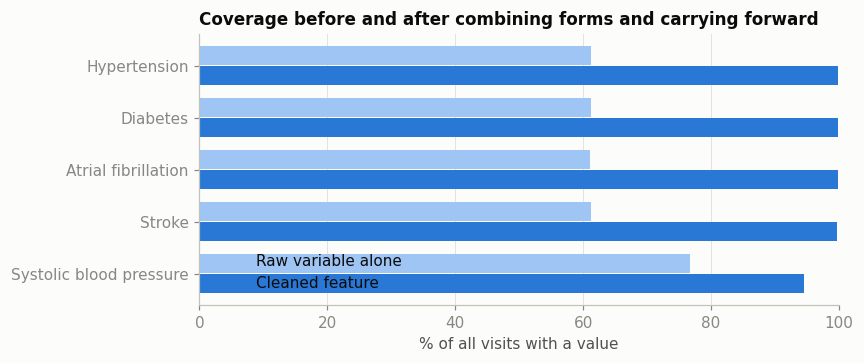

,htn_ever,chol_ever,diabetes_ever,mi_ever,afib_ever,chf_ever,revasc_ever,bypass_ever,pacemaker_ever,othercvd_ever,stroke_ever,tia_ever,smoke_ever
% at first visit,50.1,51.6,14.3,4.9,6.5,2.1,5.8,3.6,2.4,9.6,4.2,4.4,41.5


In [3]:
names = {"htn_ever": ("HYPERTEN", "Hypertension"), "diabetes_ever": ("DIABETES", "Diabetes"), "afib_ever": ("CVAFIB", "Atrial fibrillation"),
         "stroke_ever": ("CBSTROKE", "Stroke"), "bp_sys": ("BPSYS", "Systolic blood pressure")}
cov = pd.DataFrame({"Raw variable alone": [df[r].notna().mean() * 100 for r, _ in names.values()],
                    "Cleaned feature": [df[c].notna().mean() * 100 for c in names]}, index=[n for _, n in names.values()])
fig, ax = plt.subplots(figsize=(7.5, 3.2))
ypos = np.arange(len(cov))[::-1]
ax.barh(ypos + 0.19, cov["Raw variable alone"], height=0.36, color="#9ec5f4", label="Raw variable alone")
ax.barh(ypos - 0.19, cov["Cleaned feature"], height=0.36, color=nu.BLUE, label="Cleaned feature")
ax.set_yticks(ypos, cov.index); ax.set_xlim(0, 100); ax.set_xlabel("% of all visits with a value"); ax.grid(axis="y", visible=False)
ax.set_title("Coverage before and after combining forms and carrying forward"); ax.legend(loc="lower left")
nu.savefig(fig, "05_history_coverage"); plt.show()
v1 = df[df.NACCVNUM == 1]
pd.DataFrame({"% at first visit": (v1[[c for c in M.FEATURE_GROUPS["Cardiovascular / medical"] if c.endswith("_ever")]].mean() * 100).round(1)}).T

Carrying forward only ever uses the past: a visit's value depends on that visit and earlier ones. Blood pressure and BMI use the most recent in-person measurement, because telephone visits have none.

### 2.2 Cognitive tests: did the harmonisation work?

Each test score is converted to a z-score: *how far is this person from what we would expect for a healthy person of the same age, sex and education?* The expectation comes from a regression fitted on cognitively normal **training** participants at their first visit. z-scores of tests in the same domain are averaged.

If this works, two things should be true:

1. healthy participants should average about 0 in **every** UDS version, even though the tests differ;
2. the domains should fall in the order normal > impaired-not-MCI > MCI > dementia.

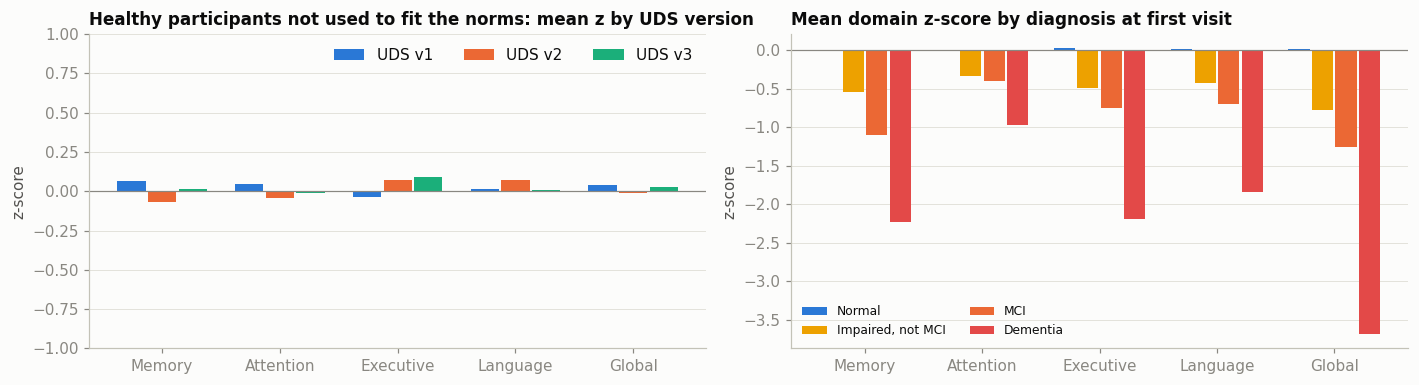

,z_memory,z_attention,z_executive,z_language,z_global
FORMVER,,,,,
UDS v1,0.07,0.05,-0.03,0.02,0.04
UDS v2,-0.07,-0.04,0.07,0.07,-0.01
UDS v3,0.01,-0.01,0.09,0.00,0.03


In [4]:
zcols = ["z_memory", "z_attention", "z_executive", "z_language", "z_global"]
cn = v1[(v1.NACCUDSD == 1) & (v1.split != "train")]          # people the norms never saw
by_ver = cn.groupby(cn.FORMVER.map({1.0: "UDS v1", 2.0: "UDS v2", 3.0: "UDS v3"}))[zcols].mean()
by_dx = v1.groupby(v1.NACCUDSD.map(nu.DX_LABELS))[zcols].mean().reindex([nu.DX_LABELS[k] for k in [1, 2, 3, 4]])
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
x = np.arange(len(zcols)); w = 0.26
for i, (ver, color) in enumerate(zip(by_ver.index, [nu.BLUE, nu.ORANGE, nu.AQUA])):
    axes[0].bar(x + (i - 1) * w, by_ver.loc[ver], width=w - 0.02, color=color, label=ver)
axes[0].set_ylim(-1, 1); axes[0].axhline(0, color=nu.MUTED, lw=0.8)
axes[0].set_title("Healthy participants not used to fit the norms: mean z by UDS version"); axes[0].legend(ncol=3)
w = 0.2
for i, dx in enumerate(by_dx.index):
    axes[1].bar(x + (i - 1.5) * w, by_dx.loc[dx], width=w - 0.02, color=list(nu.DX_COLORS.values())[i], label=dx)
axes[1].axhline(0, color=nu.MUTED, lw=0.8); axes[1].set_title("Mean domain z-score by diagnosis at first visit"); axes[1].legend(ncol=2, fontsize=8)
for ax in axes:
    ax.set_xticks(x, [c[2:].capitalize() for c in zcols]); ax.grid(axis="x", visible=False); ax.set_ylabel("z-score")
fig.tight_layout(); nu.savefig(fig, "05_cognitive_harmonisation"); plt.show()
by_ver.round(2)

Both checks pass. Healthy participants sit close to zero in every version (left), so a "memory z-score" means the same thing whether it came from Logical Memory in 2008 or Craft Story in 2018. And the domains order themselves by severity (right).

**Could not complete.** A test left undone because of cognitive or behavioural problems (code 96) is counted in `tests_failed_cognitive` instead of being filled with an average.

In [5]:
(v1.groupby(v1.NACCUDSD.map(nu.DX_LABELS)).tests_failed_cognitive.agg(["mean", lambda s: (s > 0).mean() * 100])
   .rename(columns={"mean": "Mean tests not completed", "<lambda_0>": "% with at least one"}).round(2))

,Mean tests not completed,% with at least one
NACCUDSD,,
Dementia,1.40,35.77
"Impaired, not MCI",0.06,3.44
MCI,0.06,4.32
Normal,0.03,1.26


### 2.3 What is still missing after cleaning?

Cleaning does not fill in values. Remaining gaps are left as missing and handled inside each model, using training data only.

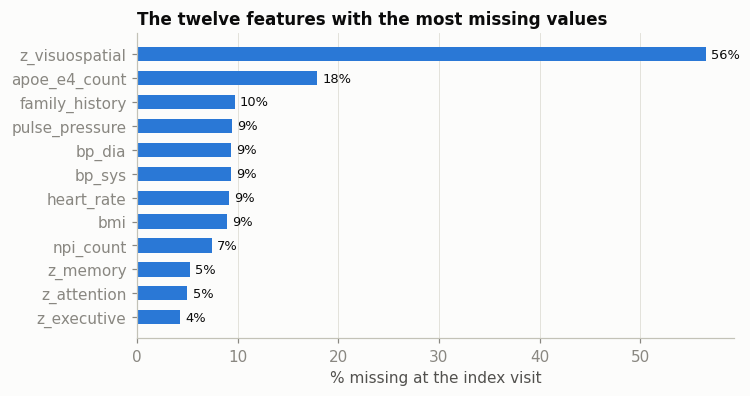

In [6]:
elig = df[df.eligible & (df.NACCVNUM == 1)]
miss = (elig[M.CORE].isna().mean() * 100).sort_values(ascending=False).head(12).round(1)
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.barh(miss.index[::-1], miss.values[::-1], color=nu.BLUE, height=0.6)
for yv, v in enumerate(miss.values[::-1]): ax.text(v + 0.5, yv, f"{v:.0f}%", va="center", fontsize=8.5)
ax.set_xlabel("% missing at the index visit"); ax.set_title("The twelve features with the most missing values"); ax.grid(axis="y", visible=False)
nu.savefig(fig, "05_remaining_missing"); plt.show()

The visuospatial score is missing for about half because that test only exists from version 3. APOE count is missing for the people who were never genotyped (flagged by `apoe_unknown`). Everything else is nearly complete.

## 3. The label

For any visit *t* where the person is not demented:

* **1** if a dementia diagnosis is recorded at a later visit within 3 years;
* **0** if the person was seen 3 or more years later and had not been diagnosed by the 3-year point;
* **unknown** otherwise (last seen before 3 years, no diagnosis). These people are not used for this target.

In [7]:
flow = pd.Series(summary["flow_baseline"]).rename("Participants").to_frame()
flow

,Participants
participants,57038
"first visit in person, UDS v1-3",55461
...and not demented,38107
...and 3-year status known,19470
...of whom converted to dementia,2818


In [8]:
e = df[df.eligible & (df.NACCVNUM == 1)]
status = pd.Series(np.where(e.y_dementia_3y == 1, "Converted within 3 years", np.where(e.y_dementia_3y == 0, "Followed 3+ years, no dementia", "Unknown (followed under 3 years)")), index=e.index)
ct = pd.crosstab(e.NACCUDSD.map(nu.DX_LABELS), status).reindex([nu.DX_LABELS[k] for k in [1, 2, 3]])
ct["% unknown"] = (ct["Unknown (followed under 3 years)"] / ct.sum(axis=1) * 100).round(1)
ct["Conversion rate among known %"] = (ct["Converted within 3 years"] / (ct["Converted within 3 years"] + ct["Followed 3+ years, no dementia"]) * 100).round(1)
ct

col_0,Converted within 3 years,"Followed 3+ years, no dementia",Unknown (followed under 3 years),% unknown,Conversion rate among known %
NACCUDSD,,,,,
Normal,198,12179,10680,46.3,1.6
"Impaired, not MCI",135,965,1428,56.5,12.3
MCI,2485,3508,6529,52.1,41.5


About half of the eligible participants have an unknown 3-year status, mostly because they enrolled recently or attended once. Leaving them out is the standard approach, and it has a cost: the cohort is tilted towards people who keep attending. The survival-analysis check planned for the validation phase uses everyone and will show whether this matters.

## 4. The cohorts

The same cleaned table supports three cohorts. Each uses a different **index visit**:

| Cohort | Index visit | Used for |
|---|---|---|
| Baseline | First visit | Tabular models, feature-group experiment |
| Longitudinal | A visit with at least two earlier visits | Does history help? |
| PET | The visit closest to the first PET scan (within one year) | Does PET help? |

In [9]:
rows = []
for key, v in summary["cohorts"].items():
    cohort, target = key.split(" | ")
    for s in M.SPLITS:
        rows.append({"Cohort": cohort, "Target": target, "Split": s, "n": v[s]["n"], "events": v[s]["events"]})
c = pd.DataFrame(rows)
c["cell"] = c.apply(lambda r: f"{r.n:,} ({r.events:,})", axis=1)
c.pivot(index=["Cohort", "Target"], columns="Split", values="cell")[M.SPLITS].rename_axis("Participants (events)", axis=1)

Participants (events)                                train          val  \
Cohort                     Target                                         
PET (visit nearest scan)   y_cdrsb_rise_3y       699 (204)     142 (35)   
                           y_dementia_2y          911 (85)     200 (11)   
                           y_dementia_3y         649 (110)     140 (21)   
baseline (first visit)     y_cdrsb_rise_3y  11,344 (2,809)  2,364 (619)   
                           y_dementia_2y    12,704 (1,063)  2,651 (228)   
                           y_dementia_3y    10,879 (1,599)  2,241 (342)   
longitudinal (third visit) y_cdrsb_rise_3y   5,732 (1,129)  1,182 (206)   
                           y_dementia_2y       6,354 (334)   1,316 (74)   
                           y_dementia_3y       5,534 (521)  1,140 (106)   

Participants (events)                              test       external  
Cohort                     Target                                       
PET (visit nearest scan)   y_cdrsb_rise_3y     139 (35)      525 (142)  
                           y_dementia_2y       189 (20)       676 (50)  
                           y_dementia_3y       133 (23)       482 (67)  
baseline (first visit)     y_cdrsb_rise_3y  2,375 (572)  4,272 (1,035)  
                           y_dementia_2y    2,729 (226)    4,827 (358)  
                           y_dementia_3y    2,286 (332)    4,064 (545)  
longitudinal (third visit) y_cdrsb_rise_3y  1,194 (211)    2,294 (469)  
                           y_dementia_2y     1,311 (79)    2,498 (129)  
                           y_dementia_3y    1,160 (108)    2,191 (202)

In [10]:
print("PET index visits:", summary["pet_index"])

PET index visits: {'participants': 3809, 'with_amyloid': 3525, 'with_tau': 1647, 'with_image': 368}


* The baseline cohort has about 10,900 training participants and 1,600 events: comfortable for any tabular model, including neural networks.
* The PET cohort is an order of magnitude smaller (about 650 training participants and 110 events at 3 years). PET models must stay small.

## 5. Leakage checklist

| Risk | How it is prevented |
|---|---|
| Same person in train and test | Split by participant; checked in section 1 |
| Test centres seen in training | 9 whole centres held out; checked in section 1 |
| Fitted cleaning steps see test data | Norms and tau scaling fitted on training participants only |
| Future information in a feature | Carry-forward, slopes and changes use only the current and earlier visits |
| The outcome hidden inside a feature | Diagnosis and CDR *at the index visit* are legitimate inputs; later values are only ever used to build the label |
| Near-duplicates of the diagnosis | FAQ, independence, memory complaint and Alzheimer's medication are kept in a separate "proximal" group and reported with and without |
| Tuning on the test set | Hyperparameters and early stopping use the validation split; test and external are scored once |

In [11]:
# A direct test of "no future information": recompute a slope using only visits up to the index and compare.
chk = df[["NACCID", "years", "CDRSUM", "slope_CDRSUM", "NACCVNUM"]].dropna()
third = chk[chk.NACCVNUM == 3]
sample = third.NACCID.sample(3000, random_state=0)
past = df.loc[(df.NACCVNUM <= 3) & df.NACCID.isin(sample), ["NACCID", "years", "CDRSUM"]].dropna()
manual = pd.Series({k: np.polyfit(g.years, g.CDRSUM, 1)[0] for k, g in past.groupby("NACCID") if len(g) == 3 and g.years.nunique() == 3}, name="manual")
both = third.set_index("NACCID").slope_CDRSUM.to_frame().join(manual, how="inner").dropna()
print(f"Slope at the third visit recomputed from visits 1-3 only for a sample of {len(both):,} participants, "
      f"largest difference {np.abs(both.slope_CDRSUM - both.manual.clip(-10, 10)).max():.2e}")

Slope at the third visit recomputed from visits 1-3 only for a sample of 3,000 participants, largest difference 7.99e-15


The stored slope equals a slope computed by hand from the first three visits only, so no later visit contributes to it.

## 6. Summary

* One cleaned table, built by a script that can be re-run from the raw files.
* Fixed splits by participant with 9 held-out centres.
* Cognitive tests harmonised across versions, and the harmonisation verified on people the norms never saw.
* A 3-year dementia label with unknown outcomes counted and excluded.
* Three cohorts (baseline, longitudinal, PET) drawn from the same table and the same split.